# Feature Importance & Redundancy Check

Diagnostic detour before Milestone 3 — not a formal milestone itself.
Uses the Milestone 2 model (`models/features_xgb.json`, trained on the raw
columns + the 6 card-aggregation features) to answer two questions:

1. Which features is the model actually relying on?
2. Are there obviously redundant columns we can drop without hurting
   PR-AUC — specifically the anonymized `V1`-`V339` columns, which are
   known (from the Kaggle competition community) to be highly collinear
   Vesta-engineered features?

Output: `../src/dropped_features.json`, a list of low-value/redundant
column names that `src/train.py --prune` will drop before training.

In [1]:
import json

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

import sys
from src.train import load_data, preprocess, time_based_split
from src.features import add_card_aggregate_features

## Rebuild the exact training data

Reusing `src.train`'s own functions (rather than re-implementing the
pipeline here) guarantees this analysis sees precisely what the trained
model saw — same columns, same split, same preprocessing.

In [2]:
df = load_data()
df = add_card_aggregate_features(df)
df = preprocess(df)
train_df, val_df = time_based_split(df)

drop_cols = ['isFraud', 'TransactionID', 'TransactionDT']
feature_cols = [c for c in df.columns if c not in drop_cols]
X_train = train_df[feature_cols]

print(f'{len(feature_cols)} features, {len(train_df)} training rows')

429 features, 472432 training rows


## Load the trained model and get gain-based importance

Gain (average improvement in the loss from splits using this feature) is
more meaningful than raw split-count for deciding what to prune — a
feature can be split on often but contribute almost nothing to accuracy
each time.

In [3]:
booster = xgb.Booster()
booster.load_model('models/features_xgb.json')

gain = booster.get_score(importance_type='gain')
# XGBoost only returns scores for features it actually split on at least
# once -- anything NOT in this dict had zero importance by definition.
importance = pd.Series(gain, name='gain').reindex(feature_cols, fill_value=0.0)
importance = importance.sort_values(ascending=False)

print(f'{(importance == 0).sum()} of {len(importance)} features were never split on (zero importance)')

56 of 429 features were never split on (zero importance)


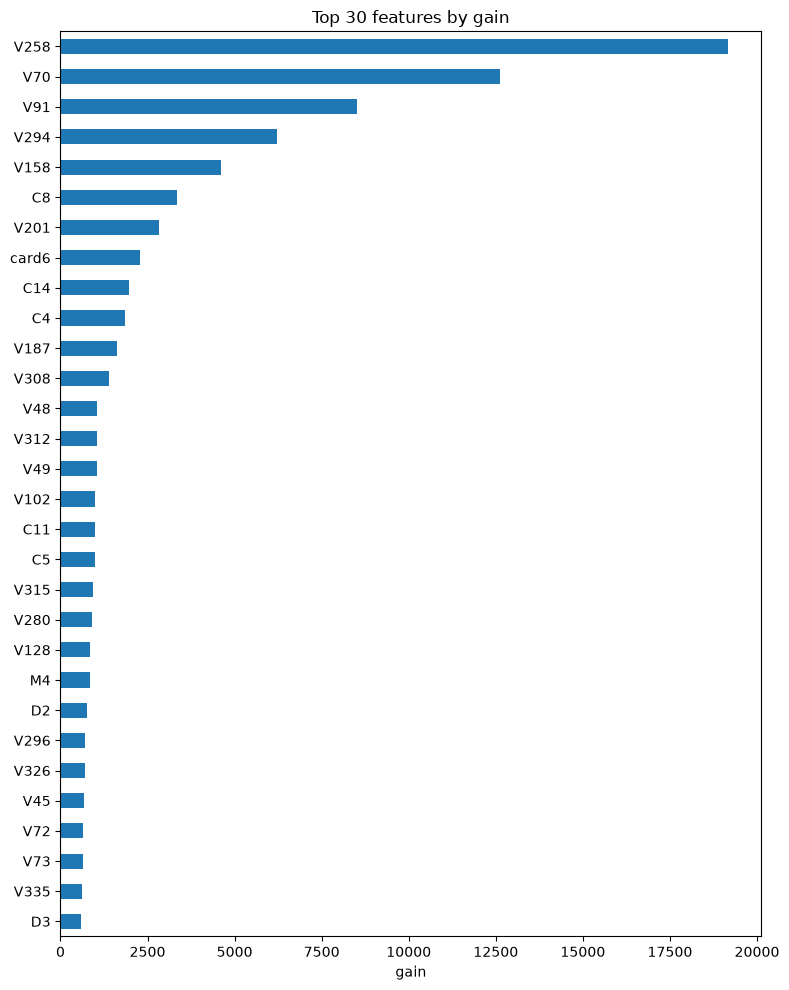

In [4]:
top_n = 30
importance.head(top_n).sort_values().plot(kind='barh', figsize=(8, 10), title=f'Top {top_n} features by gain')
plt.xlabel('gain')
plt.tight_layout()
plt.show()

In [5]:
importance.head(15)

V258     19167.169922
V70      12616.071289
V91       8520.080078
V294      6212.741211
V158      4610.947754
C8        3344.745361
V201      2829.402100
card6     2274.775391
C14       1962.655640
C4        1856.800049
V187      1634.372925
V308      1388.865356
V48       1058.507690
V312      1050.765991
V49       1038.227661
Name: gain, dtype: float64

Zero-importance features — the model never found a useful split on these,
so they're pure noise/overhead as far as this model is concerned. First
prune candidate set.

In [6]:
zero_importance_features = importance[importance == 0].index.tolist()
print(f'{len(zero_importance_features)} zero-importance features')
zero_importance_features[:20]

56 zero-importance features


['V106',
 'V1',
 'V110',
 'id_16',
 'V107',
 'id_28',
 'id_12',
 'id_29',
 'V93',
 'V89',
 'V241',
 'V71',
 'V68',
 'id_35',
 'V65',
 'V112',
 'V57',
 'V41',
 'V39',
 'V32']

## Redundant V-column clusters

Restricted to `V1`-`V339` and computed on the **training split only**
(never validation — this is a feature-selection decision, and using
validation data to make it would be a subtle form of leakage into the
model-selection process, even though it wouldn't affect the trained
model's weights directly).

Greedy approach: walk columns in order, and for each one not yet marked
redundant, mark any later column correlated with it above the threshold
as redundant (keeping the earlier one). Simple and sufficient for a
diagnostic pass — not trying to find a globally optimal minimal set.

In [7]:
v_cols = [c for c in feature_cols if c.startswith('V')]
corr = X_train[v_cols].corr().abs()

CORR_THRESHOLD = 0.95
redundant_v_cols = set()
for i, col_i in enumerate(v_cols):
    if col_i in redundant_v_cols:
        continue
    for col_j in v_cols[i + 1:]:
        if col_j in redundant_v_cols:
            continue
        if corr.loc[col_i, col_j] > CORR_THRESHOLD:
            redundant_v_cols.add(col_j)

redundant_v_cols = sorted(redundant_v_cols)
print(f'{len(redundant_v_cols)} of {len(v_cols)} V-columns are redundant '
      f'(correlation > {CORR_THRESHOLD} with an earlier column)')

71 of 339 V-columns are redundant (correlation > 0.95 with an earlier column)


## Combine and save the prune list

Union of zero-importance features and redundant V-columns. A column can
be in both sets (often is, in practice — a redundant duplicate is also
unlikely to have been selected for splits alongside its twin).

In [8]:
dropped_features = sorted(set(zero_importance_features) | set(redundant_v_cols))
print(f'{len(dropped_features)} features to drop out of {len(feature_cols)} '
      f'({len(dropped_features) / len(feature_cols):.0%})')

with open('src/dropped_features.json', 'w') as f:
    json.dump(dropped_features, f, indent=2)
print('Saved to src/dropped_features.json')

116 features to drop out of 429 (27%)
Saved to src/dropped_features.json


## Findings

116 of 429 features (27%) were dropped: 56 the model never split on at all
(zero gain), plus 71 V-columns redundant with an earlier, more-correlated
V-column (threshold 0.95). Some overlap between the two sets, as expected.

Re-running `python -m src.train --prune`: **PR-AUC 0.520 -> 0.521** —
essentially unchanged, slightly up — with 27% fewer features. This is a
genuinely useful result: a large chunk of the anonymized V-columns really
were redundant duplicates of each other, not independent signal. A smaller
feature set is also a nice property to have (faster training, easier to
reason about) with no accuracy cost here.

Not pursued further this pass: iterating the correlation threshold, or
re-running the whole importance analysis on the pruned model to see if a
second pruning round finds anything else. Diminishing returns for a
portfolio project relative to just moving on to Milestone 3.
